# Sobre o Notebook

Este notebook realiza o cálculo de métricas, análises estatísticas e visualizações sobre conversas geradas pelo notebook **`network_simulator.ipynb`** https://github.com/EvaldoBritoJunior/network_simulator_replication_project/blob/main/Notebooks/network_simulator.ipynb

As análises estão organizadas em dois objetivos principais:

- **O1 – Comparação entre conversas simuladas e conversas reais**, utilizando o conjunto de dados **Twitter16**;
- **O2 – Análise dos efeitos de conteúdos verdadeiros e falsos** sobre as conversas simuladas.

---

## Requisitos

Para executar este notebook, são necessários os seguintes conjuntos de dados.

### 1. Arquivos gerados pelo `network_simulator.ipynb`

São necessários os arquivos CSV gerados pelo notebook de simulação:

- **`true_x_messages.csv`** e **`false_x_messages.csv`**, onde:
  - `x` identifica a conversa simulada;
  - `true` e `false` indicam se a notícia que originou a conversa corresponde, respectivamente, a um conteúdo verdadeiro ou falso.

  Esses arquivos devem conter:
  - as mensagens da conversa (`message`);
  - as métricas linguísticas contínuas calculadas para cada mensagem:
    - `bias_words`, `assertatives`, `factives`, `hedges`, `implicatives`, `report_verbs`,
      `positive_opinion_words`, `negative_opinion_words` e `polarity`.

- **`true_x_metrics.csv`** e **`false_x_metrics.csv`**, contendo as métricas estruturais calculadas para cada conversa:
  - `H`, `A`, `leaves`, `nodes` e `has_drift`.

### 2. Conjunto de dados Twitter16

São necessários os seguintes componentes do conjunto de dados **Twitter16**:

- **`source_tweets.txt`**: contém as mensagens que originam cada conversa;
- **`label.txt`**: informa o rótulo de veracidade associado a cada mensagem inicial;
- **Diretório `tree`**: contém as árvores de conversação, representadas por identificadores (IDs) dos tweets, que descrevem a estrutura de resposta de cada conversa;
- **`tweets_text.csv`**: contém as mensagens recuperadas do Twitter16 pela API do X.

---

## Download dos dados

Atualmente, os conjuntos de dados acima são baixados automaticamente do **Google Drive**.

Caso deseje utilizar outros arquivos ou o conteúdo deixe de estar disponível, basta modificar as células que contêm chamadas para:

```python
gdown.download
```

substituindo os links pelos arquivos desejados.

# Configuração do Ambiente

Instalando Dependências

In [1]:
!pip install transformers torch -q
!pip install -q gdown
!pip -q install rpy2
!pip install -q emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 22.4 MB/s eta 0:00:00


In [2]:
# Data manipulation and file handling
import os
import csv
import glob
import zipfile
import urllib.request
from pathlib import Path

import pandas as pd
import numpy as np

# Download and data access utilities
import kagglehub
import gdown
import requests

# Natural Language Processing and Transformers
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax

# Statistical analysis and hypothesis tests
from scipy.stats import shapiro, levene, normaltest, ttest_ind, mannwhitneyu, fisher_exact, median_test
from scipy.stats.contingency import chi2_contingency

# Machine Learning and Deep Learning
import torch

# Text processing and feature extraction
import re
import string
import emoji
from collections import Counter

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import time

In [3]:
# Show all columns
pd.set_option('display.max_columns', None)

Criando Tabelas

In [6]:
# Download the 'simulated_conversations.zip' file from Google Drive.
# It contains the files generated by running the network simulator notebook (ipynb).
file_id = "1KgIL-0k1M6lYlKSOLGem-sHMWGAhhVNZ"
zip_path = "simulated_conversations.zip"
gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    zip_path,
    quiet=False
)

# Extract
extract_dir = Path("")
extract_dir.mkdir(exist_ok=True)
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

data_path = Path("/content/generated data")

Downloading...
From: https://drive.google.com/uc?id=1KgIL-0k1M6lYlKSOLGem-sHMWGAhhVNZ
To: /content/simulated_conversations.zip
100%|██████████| 709k/709k [00:00<00:00, 28.6MB/s]


In [7]:
# Create the 'df_all' DataFrame with the continuous metrics
pattern = re.compile(r"^(true|false)_(\d+)_messages\.csv$")

dfs = []

for filepath in data_path.glob("*.csv"):
    filename = filepath.name

    # Ignores files that do not follow the pattern
    match = pattern.match(filename)
    if not match:
        continue

    df = pd.read_csv(filepath)
    df["origin"] = filepath.stem
    df["framing"] = (match.group(1) == "true")

    dfs.append(df)

# Concatenates all DataFrames
df_all = pd.concat(dfs, ignore_index=True)

print(f"\nShape final: {df_all.shape}")
display(df_all.head())


Shape final: (11860, 12)


,bias words,assertatives,factives,hedges,implicatives,report verbs,positive opinion words,negative opinion words,message,polarity,origin,framing
0,0.119048,0.02381,0.02381,0.00000,0.00000,0.02381,0.02381,0.00000,"Wow, if Elon says it, then it's serious! 😱 He ...",0.959693,false_24_messages,False
1,0.187500,0.03125,0.03125,0.03125,0.03125,0.06250,0.03125,0.00000,Totally agree! If anyone can turn things aroun...,0.968992,false_24_messages,False
2,0.075000,0.00000,0.00000,0.00000,0.00000,0.00000,0.07500,0.02500,Absolutely! Elon has a knack for pulling off m...,0.495050,false_24_messages,False
3,0.125000,0.00000,0.00000,0.06250,0.00000,0.03125,0.06250,0.03125,Absolutely! Elon’s a genius at making comeback...,0.329815,false_24_messages,False
4,0.093750,0.00000,0.03125,0.00000,0.00000,0.03125,0.03125,0.00000,@user_9 Absolutely! Elon always finds a way to...,0.968992,false_24_messages,False


In [8]:
# Create the 'df_all_multinomial' DataFrame with the multinomial metrics
pattern = re.compile(r"^(true|false)_(\d+)_metrics\.csv$")

dfs = []

for filepath in data_path.glob("*.csv"):
    filename = filepath.name

    # Ignores files that do not follow the pattern
    match = pattern.match(filename)
    if not match:
        continue

    df = pd.read_csv(filepath)
    df["origin"] = filepath.stem
    df["framing"] = (match.group(1) == "true")

    dfs.append(df)

# Concatenates all DataFrames
df_all_multinomial = pd.concat(dfs, ignore_index=True)

print(f"\nShape final: {df_all.shape}")
display(df_all_multinomial.head())


Shape final: (11860, 12)


,H,A,leaves,nodes,has_drift,origin,framing
0,6,107,173,208,False,true_27_metrics,True
1,7,122,185,216,True,true_29_metrics,True
2,7,106,172,199,False,true_13_metrics,True
3,6,108,168,200,True,false_25_metrics,False
4,7,113,171,206,False,false_4_metrics,False


Pré-processamento

In [9]:
# Preprocess text (anonymize @user and http links)
def preprocess(text):
    text = str(text)

    text = re.sub(r'(^|\s)\.?@\w+', r'\1@user', text)
    text = re.sub(r'https?://\S+', '_http', text)

    return text

df_all["message"] = df_all["message"].astype(str).apply(preprocess)

Calculando Métricas Adicionais

In [10]:
# Convert text to lowercase and extract words
def tokenize(text):
    return re.findall(r"\b[\w'-]+\b", str(text).lower())

# Count the number of emojis in the text
def count_emojis(text):
    text = str(text)
    return len(emoji.emoji_list(text))

def compute_metrics(df, text_col):
    df = df.copy()
    df["words"] = df[text_col].apply(tokenize)

    # Number of words in each text
    df["word_length"] = df["words"].apply(len)
    # Number of characters in each text
    df["char_length"] = (
        df[text_col]
        .astype(str)
        .str.len()
    )
    # Number of emojis in each text
    df["emoji_count"] = (
        df[text_col]
        .apply(count_emojis)
    )

    return df

# Compute metrics
df_all_metrics = compute_metrics(df_all, "message")

ns_smallest = (
    df_all_metrics
    .sort_values(
        by=["char_length"],
        ascending=[True]
    )
)

display(ns_smallest)

,bias words,assertatives,factives,hedges,implicatives,report verbs,positive opinion words,negative opinion words,message,polarity,origin,framing,words,word_length,char_length,emoji_count
9899,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,That's not true. 🤔,0.000000,true_16_messages,True,"[that's, not, true]",3,18,1
5765,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"Wait, what? Is this for real? 😮",0.000000,false_12_messages,False,"[wait, what, is, this, for, real]",6,31,1
5772,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"Wait, what? Is this for real? 🤔",0.000000,false_12_messages,False,"[wait, what, is, this, for, real]",6,31,1
9869,0.222222,0.111111,0.000000,0.000000,0.000000,0.111111,0.000000,0.000000,"Nah, I don't think that's true. 🤔",0.000000,true_16_messages,True,"[nah, i, don't, think, that's, true]",6,33,1
5683,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.125000,Is this true or just another rumor? 🤔,-0.992063,false_12_messages,False,"[is, this, true, or, just, another, rumor]",7,37,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1079,0.131148,0.000000,0.000000,0.049180,0.016393,0.016393,0.065574,0.016393,"Honestly, it's no surprise consumer confidence...",0.592768,true_1_messages,True,"[honestly, it's, no, surprise, consumer, confi...",54,330,1
8754,0.179104,0.000000,0.014925,0.014925,0.000000,0.014925,0.044776,0.029851,"Wow, that’s crazy! 😮 But honestly, Bill Gates ...",0.197355,false_21_messages,False,"[wow, that, s, crazy, but, honestly, bill, gat...",61,343,4
8532,0.123077,0.000000,0.015385,0.000000,0.015385,0.046154,0.076923,0.000000,"Wow, Netflix really went for a switch-up! 🤔 It...",0.987167,false_27_messages,False,"[wow, netflix, really, went, for, a, switch-up...",61,345,2
8759,0.179104,0.000000,0.000000,0.014925,0.029851,0.014925,0.149254,0.014925,"I mean, Bill Gates and his smart city plans ar...",0.813229,false_21_messages,False,"[i, mean, bill, gates, and, his, smart, city, ...",60,358,3


In [11]:
char_length_stats = (
    df_all_metrics[["char_length"]]
    .describe()
    .T
    .round(2)
)

display(char_length_stats)

,count,mean,std,min,25%,50%,75%,max
char_length,11860.0,147.36,43.49,18.0,117.0,145.0,175.0,370.0


# O1: Comparando conversas online com textos simulados

## Preparação

In [12]:
# Download the 'Twitter16.zip' file from Google Drive, containing source_tweets.txt, label.txt, and the tree directory
file_id = "1hL5-69RShCS0TrKIz6zCtkrZBaqBVaTx"
zip_path = "Twitter16.zip"
gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    zip_path,
    quiet=False
)

# Extract
extract_dir = Path("")
extract_dir.mkdir(exist_ok=True)
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

twitter16_path = Path("/content/twitter16")

# Extracting tweet IDs from trees in the files
tree_dir = twitter16_path / "tree"
conversations = []
tweet_tuple_pattern = re.compile(
    r"\['(\d+)',\s*'(\d+)',\s*'(\d+(?:\.\d+)?)'\]"
)

for tree_file in tree_dir.iterdir():

    root_tweet_id = tree_file.stem

    with open(tree_file, encoding="utf-8", errors="ignore") as f:

        for line in f:
            tuples = tweet_tuple_pattern.findall(line)
            for tweet_tuple in tuples:
              conversations.append({
                  "root_tweet_id": root_tweet_id,
                  "uid": tweet_tuple[0],
                  "tweet ID": tweet_tuple[1],
                  "post time delay (minutes)": tweet_tuple[2]
              })

conversation_df = pd.DataFrame(conversations)
conversation_df = conversation_df.drop_duplicates().reset_index(drop=True)

display(conversation_df)

Downloading...
From: https://drive.google.com/uc?id=1hL5-69RShCS0TrKIz6zCtkrZBaqBVaTx
To: /content/Twitter16.zip
100%|██████████| 4.28M/4.28M [00:00<00:00, 16.1MB/s]


,root_tweet_id,uid,tweet ID,post time delay (minutes)
0,614608936491188225,17446621,614608936491188225,0.0
1,614608936491188225,177497596,614608936491188225,0.18
2,614608936491188225,2599740468,614608936491188225,0.2
3,614608936491188225,380471202,614608936491188225,0.22
4,614608936491188225,636691413,614608936491188225,0.23
...,...,...,...,...
347624,693321561542127616,289105516,693321561542127616,3059.97
347625,693321561542127616,3293736557,694099766557409280,3092.3
347626,693321561542127616,228097533,693321561542127616,5469.67
347627,693321561542127616,925649760,693321561542127616,9420.18


In [13]:
# Removing reposts (leaving new comments)
before = len(conversation_df)

conversation_df = (
    conversation_df
    .drop_duplicates(subset=["root_tweet_id", "tweet ID"], keep="first")
    .reset_index(drop=True)
)

after = len(conversation_df)

print(f"Removed {before - after} reposts.")
print(f"Remaining total: {after}")
display(conversation_df)

Removed 320958 reposts.
Remaining total: 26671


,root_tweet_id,uid,tweet ID,post time delay (minutes)
0,614608936491188225,17446621,614608936491188225,0.0
1,614608936491188225,373115412,614609461085347840,2.1
2,614608936491188225,2858960541,614609788786245633,3.4
3,614608936491188225,28357582,614612574496288768,14.47
4,614608936491188225,769702230,614612787336249344,15.32
...,...,...,...,...
26666,693321561542127616,458768756,693407391954669568,341.05
26667,693321561542127616,336474640,693416368704765952,376.73
26668,693321561542127616,423914278,693573061388439552,999.37
26669,693321561542127616,1491562196,693660136804634624,1345.37


In [14]:
# Download the 'tweets_text.csv' file from Google Drive, containing the text of 1,027 tweets from Twitter16

file_id = "1wyJ_8nqRNSHzkjN-ywE2dXk_hhDLrxyj"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "tweets_text.csv", quiet=False)

df_t16 = pd.read_csv("tweets_text.csv")

display(df_t16.head())
print(df_t16.shape)

Downloading...
From: https://drive.google.com/uc?id=1wyJ_8nqRNSHzkjN-ywE2dXk_hhDLrxyj
To: /content/tweets_text.csv
100%|██████████| 167k/167k [00:00<00:00, 55.9MB/s]


,tweet_id,conversation_id,author_id,created_at,text
0,689267711856263168,689267711856263168,5402612,2016-01-19 02:06:43+00:00,"China's economy grew by 6.9% in 2015, marking ..."
1,637873886072320001,637873886072320001,759251,2015-08-30 06:26:00+00:00,Sanders closes to 7 points behind Clinton in n...
2,524925215235911680,524925215235911680,8736882,2014-10-22 14:08:18+00:00,#BREAKING news: Shots fired at Parliament Hill...
3,693935557009801218,693935557009801218,1367531,2016-01-31 23:15:04+00:00,Iran's supreme leader awards medals to troops ...
4,724603564946010112,724603564946010112,457984599,2016-04-25 14:18:47+00:00,Twenty-Five Stories Proving Target’s Pro-Trans...


(1027, 5)


## Número de comentários por conversa

Criando tabela para comparação

In [ ]:
# Twitter16 number of new comments per conversation
t16_comments_per_conversation = (
    conversation_df
    .groupby("root_tweet_id")
    .agg(
        n_comments=("root_tweet_id", "size")
    )
    .reset_index()
)

# Network Simulator number of new comments per conversation
ns_comments_per_conversation = (
    df_all
    .groupby("origin")
    .agg(n_comments=("message", "count"))
    .reset_index()
)

# Adds dataset identification
t16_plot = t16_comments_per_conversation.copy()
t16_plot["dataset"] = "T16"

ns_plot = ns_comments_per_conversation.copy()
ns_plot["dataset"] = "NS"

# Joins the tables
comparison = pd.concat([
    t16_plot[["dataset", "n_comments"]],
    ns_plot[["dataset", "n_comments"]]
], ignore_index=True)

display(comparison)

,dataset,n_comments
0,T16,7
1,T16,13
2,T16,14
3,T16,11
4,T16,9
...,...,...
875,NS,182
876,NS,194
877,NS,198
878,NS,199


In [ ]:
# Descriptive statistics for the number of comments per conversation in T16
t16_comments_stats = (
    t16_comments_per_conversation[["n_comments"]]
    .describe()
    .T
    .round(2)
)

display(t16_comments_stats)

,count,mean,std,min,25%,50%,75%,max
n_comments,818.0,32.61,42.64,1.0,8.0,18.0,38.0,365.0


In [ ]:
# Descriptive statistics for the number of comments per conversation in NS
comments_stats = (
    ns_comments_per_conversation[["n_comments"]]
    .describe()
    .T
    .round(2)
)

display(comments_stats)

,count,mean,std,min,25%,50%,75%,max
n_comments,62.0,191.29,11.49,163.0,184.0,191.0,198.0,228.0


Teste da Mediana

In [ ]:
# Separate the samples by dataset
groups = [
    group["n_comments"].dropna().values
    for _, group in comparison.groupby("dataset")
]

# Perform the independent-samples median test
stat, p_value, median, contingency = median_test(*groups)

alpha = 0.005

print("--- Median Independent-Samples Test ---")
print(f"Overall median: {median:.3f}")
print(f"Chi-square statistic: {stat:.4f}")
print(f"p-value: {p_value:.9f}")

if p_value < alpha:
    print(f"Result: Significant (p < {alpha})")
else:
    print(f"Result: Not Significant (p ≥ {alpha})")

# Report if the result meets the more stringent significance threshold
if p_value < 0.001:
    print("Interpretation: p < 0.001")

--- Median Independent-Samples Test ---
Overall median: 20.000
Chi-square statistic: 68.5609
p-value: 0.000000000
Result: Significant (p < 0.005)
Interpretation: p < 0.001


Representações visuais

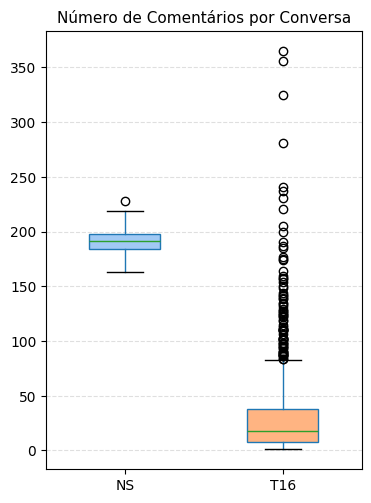

In [ ]:
fig, ax = plt.subplots(
    figsize=(3.6, 5),
    constrained_layout=True
)

cores = sns.color_palette("pastel")

comparison.boxplot(
    column="n_comments",
    by="dataset",
    ax=ax,
    grid=False,
    widths=0.45,
    patch_artist=True
)

for patch, cor in zip(ax.patches, cores):
    patch.set_facecolor(cor)

fig.suptitle("")

ax.set_title("Número de Comentários por Conversa", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("")

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

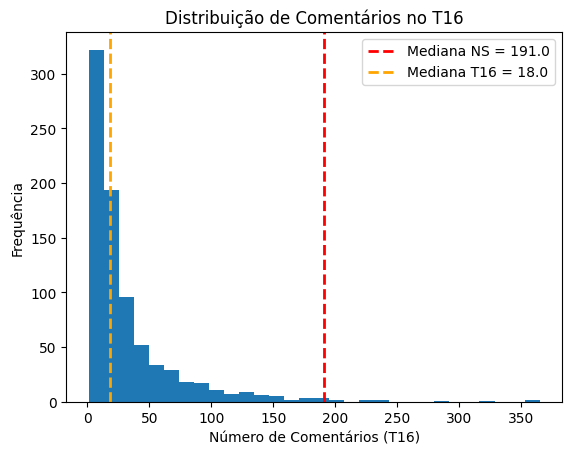

In [ ]:
plt.hist(
    t16_comments_per_conversation["n_comments"],
    bins=30
)

ns_value = ns_comments_per_conversation["n_comments"].median()
t16_value = t16_comments_per_conversation["n_comments"].median()

plt.axvline(
    ns_value,
    linestyle="--",
    linewidth=2,
    label=f"Mediana NS = {ns_value}",
    color="red"
)

plt.axvline(
    t16_value,
    linestyle="--",
    linewidth=2,
    label=f"Mediana T16 = {t16_value}",
    color="orange"
)

plt.title("Distribuição de Comentários no T16")
plt.xlabel("Número de Comentários (T16)")
plt.ylabel("Frequência")
plt.legend()

plt.show()

## Ocorrências de http ou https

In [ ]:
# Count occurrences of HTTP and HTTPS links in a text
def count_http(text):
    return len(re.findall(r'https?://|http', str(text), flags=re.IGNORECASE))

# Compute the HTTP link count for each message
df_t16_metrics = df_t16.copy()
df_t16_metrics["http_count"] = df_t16_metrics["text"].apply(count_http)

df_all_http_metrics = df_all.copy()
df_all_http_metrics["http_count"] = df_all_http_metrics["message"].apply(count_http)

# Combine both datasets for comparison
comparison = pd.concat([
    df_t16_metrics[["http_count"]].assign(dataset="T16"),
    df_all_http_metrics[["http_count"]].assign(dataset="NS")
], ignore_index=True)

# Generate descriptive statistics for each dataset
summary = (
    comparison
    .groupby("dataset")["http_count"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(3)
)

display(summary)

,mean,median,std,min,max
dataset,,,,,
NS,0.000,0.0,0.00,0,0
T16,0.936,1.0,0.82,0,2


In [ ]:
# Percentage distribution of T16
http_pct = (
    df_t16_metrics["http_count"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename("percentage")
    .reset_index()
)

display(http_pct)

,http_count,percentage
0,0,37.000974
1,1,32.424537
2,2,30.574489


## Tamanho das Mensagens em Palavras e Caracteres

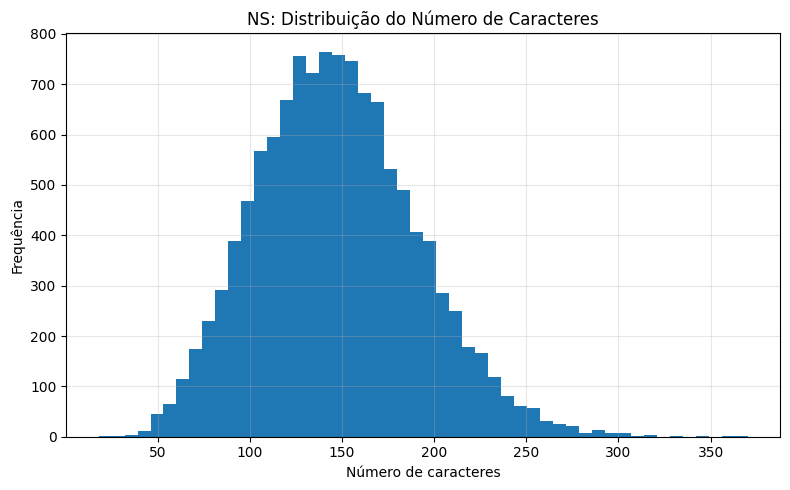

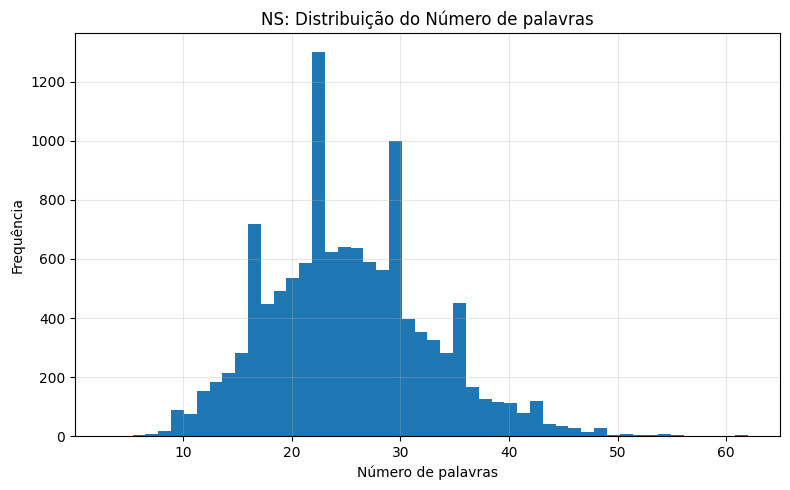

In [ ]:
# NS char_length histogram
plt.figure(figsize=(8, 5))
plt.hist(df_all_metrics["char_length"].dropna(), bins=50)
plt.title("NS: Distribuição do Número de Caracteres")
plt.xlabel("Número de caracteres")
plt.ylabel("Frequência")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# NS word_length histogram
plt.figure(figsize=(8, 5))
plt.hist(df_all_metrics["word_length"].dropna(), bins=50)
plt.title("NS: Distribuição do Número de palavras")
plt.xlabel("Número de palavras")
plt.ylabel("Frequência")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Criando tabela para comparação

In [ ]:
# Compute text-based metrics for the T16 dataset
df_t16_metrics = compute_metrics(df_t16, "text")

# Merge both datasets into a single DataFrame with a common schema
df_t16_metrics["dataset"] = "T16"
df_all_metrics["dataset"] = "NS"

comparison = pd.concat([
    df_t16_metrics[["dataset", "text", "words", "word_length", "char_length", "emoji_count"]],
    df_all_metrics.rename(
        columns={"message": "text"})[
            ["dataset", "text", "words", "word_length", "char_length", "emoji_count"]
        ]
], ignore_index=True)

display(comparison.head())

,dataset,text,words,word_length,char_length,emoji_count
0,T16,"China's economy grew by 6.9% in 2015, marking ...","[china's, economy, grew, by, 6, 9, in, 2015, m...",16,83,0
1,T16,Sanders closes to 7 points behind Clinton in n...,"[sanders, closes, to, 7, points, behind, clint...",13,71,0
2,T16,#BREAKING news: Shots fired at Parliament Hill...,"[breaking, news, shots, fired, at, parliament,...",12,84,0
3,T16,Iran's supreme leader awards medals to troops ...,"[iran's, supreme, leader, awards, medals, to, ...",14,86,0
4,T16,Twenty-Five Stories Proving Target’s Pro-Trans...,"[twenty-five, stories, proving, target, s, pro...",11,81,0


In [ ]:
# Descriptive statistics
summary = (
    comparison
    .groupby("dataset")
    .agg(
        mean_word_length=("word_length", "mean"),
        median_word_length=("word_length", "median"),
        std_word_length=("word_length", "std"),

        mean_char_length=("char_length", "mean"),
        median_char_length=("char_length", "median"),
        std_char_length=("char_length", "std"),

        mean_emoji_count=("emoji_count", "mean"),
        median_emoji_count=("emoji_count", "median"),
        std_emoji_count=("emoji_count", "std")
    )
    .round(2)
    .reset_index()
)

display(summary)

,dataset,mean_word_length,median_word_length,std_word_length,mean_char_length,median_char_length,std_char_length,mean_emoji_count,median_emoji_count,std_emoji_count
0,NS,25.31,25.0,7.51,147.36,145.0,43.49,2.03,2.0,0.76
1,T16,14.56,15.0,5.32,86.58,91.0,29.98,0.09,0.0,1.35


Teste da Mediana

In [ ]:
# Perform the independent-samples median test
alpha = 0.005
variables = ["word_length", "char_length"]

results = []

for var in variables:
    groups = [
        group[var].dropna().values
        for _, group in comparison.groupby("dataset")
    ]
    stat, p_value, median, contingency = median_test(*groups)

    results.append({
        "variable": var,
        "median": median,
        "chi_square": stat,
        "p_value": p_value,
        "result": "Significant" if p_value < alpha else "Not Significant"
    })

# Show results
results_df = pd.DataFrame(results)
print(results_df)

      variable  median   chi_square        p_value       result
0  word_length    24.0   921.814640  1.776817e-202  Significant
1  char_length   141.0  1068.979742  1.824099e-234  Significant


Representações visuais

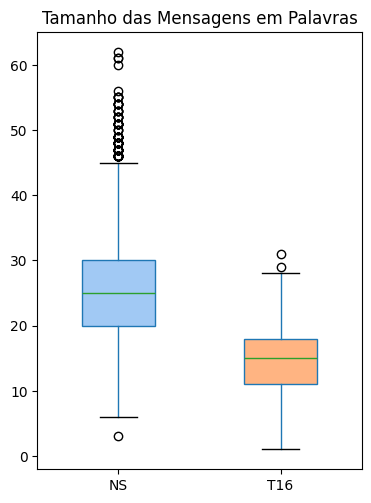

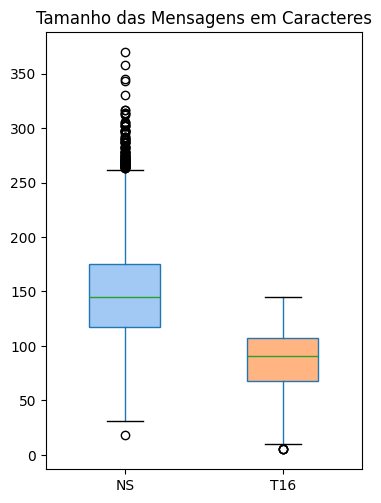

In [ ]:
metrics = [
    ("word_length", "Tamanho das Mensagens em Palavras"),
    ("char_length", "Tamanho das Mensagens em Caracteres")
]

for metric in metrics:

    fig, ax = plt.subplots(
        figsize=(3.6, 5),
        constrained_layout=True
    )

    comparison.boxplot(
        column=metric[0],
        by="dataset",
        ax=ax,
        grid=False,
        widths=0.45,
        patch_artist=True
    )

    for patch, cor in zip(ax.patches, cores):
      patch.set_facecolor(cor)

    plt.title(metric[1])
    plt.suptitle("")
    plt.xlabel("")
    plt.ylabel("")

    plt.show()

## Número de Emojis

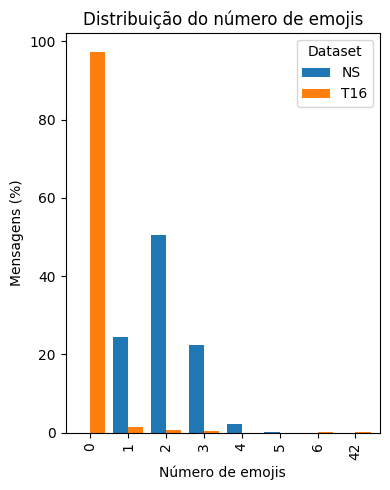

In [ ]:
# Absolute frequency of emoji counts for each dataset
freq = (
    comparison
    .groupby(["dataset", "emoji_count"])
    .size()
    .unstack(fill_value=0)
    .T
)

# Convert absolute frequencies to percentages
freq_pct = freq.div(freq.sum(axis=0), axis=1) * 100

# Plot
ax = freq_pct.plot(
    kind="bar",
    figsize=(4, 5),
    width=0.8
)

ax.set_xlabel("Número de emojis")
ax.set_ylabel("Mensagens (%)")
ax.set_title("Distribuição do número de emojis")
ax.legend(title="Dataset")

plt.tight_layout()
plt.show()

In [ ]:
print(freq_pct)

dataset             NS        T16
emoji_count                      
0             0.000000  97.273612
1            24.510961   1.460565
2            50.615514   0.584226
3            22.436762   0.486855
4             2.242833   0.000000
5             0.177066   0.000000
6             0.016863   0.097371
42            0.000000   0.097371


## Sinais de Pontuação

In [ ]:
# Define the set of punctuation characters to analyze, excluding the underscore
PUNCTS = string.punctuation.replace("_", "")

def punctuation_counts(text):
    c = Counter(ch for ch in text if ch in PUNCTS)
    return {p: c[p] for p in PUNCTS}

# Compute punctuation counts for each message
counts = comparison["text"].apply(punctuation_counts).apply(pd.Series)
counts["dataset"] = comparison["dataset"]

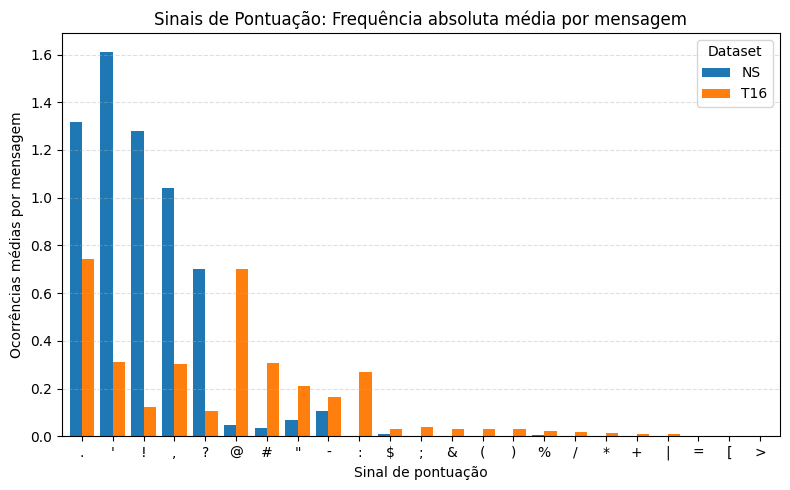

In [ ]:
# Compute the average number of occurrences of each punctuation mark per message
mean_counts = (
    counts
    .groupby("dataset")
    .mean()
    .T
)

# Remove punctuation marks that never appear in either dataset
mean_counts = mean_counts.loc[mean_counts.sum(axis=1) > 0]

# Sort punctuation marks by their overall average frequency
mean_counts["total"] = mean_counts.sum(axis=1)
mean_counts = (
    mean_counts
    .sort_values("total", ascending=False)
    .drop(columns="total")
)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

mean_counts.plot(
    kind="bar",
    ax=ax,
    width=0.8
)

ax.set_xlabel("Sinal de pontuação")
ax.set_ylabel("Ocorrências médias por mensagem")
ax.set_title("Sinais de Pontuação: Frequência absoluta média por mensagem")

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Dataset")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Amostras de mensagens

In [ ]:
# Sample of 30 NS messages
ns_sample = (
    df_all[["message"]]
    .sample(n=30, random_state=42)
    .rename(columns={"message": "text"})
)
ns_sample["origin"] = "NS"

# Sample of 30 T16 messages
t16_sample = (
    df_t16.loc[
        ~df_t16["text"].str.contains("_http", regex=False, na=False),
        ["text"]
    ]
    .sample(n=30, random_state=42)
    .copy()
)
t16_sample["origin"] = "T16"

# Gather and shuffle
sample_df = (
    pd.concat([ns_sample, t16_sample], ignore_index=True)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

display(sample_df.head(3))

,text,origin
0,"Man, that's crazy! 😳 It's so important to have...",NS
1,Absolutely! 🙌 It's all about putting our peopl...,NS
2,#BREAKING Gunman in policewoman killing suspec...,T16


# O2 Efeitos de conteúdo verdadeiro e falso em conversas simuladas

## Preparação

Calculando polaridade conforme o paper original

In [ ]:
df_all['polarity'] = (df_all['positive opinion words']-df_all['negative opinion words'])/(df_all['positive opinion words']+df_all['negative opinion words']+0.001)

Baixando o modelo RoBERTa

In [ ]:
task='sentiment'
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"

tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

# Download label mapping
labels=[]
mapping_link = f"https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/{task}/mapping.txt"
with urllib.request.urlopen(mapping_link) as f:
    html = f.read().decode('utf-8').split("\n")
    csvreader = csv.reader(html, delimiter='\t')
labels = [row[1] for row in csvreader if len(row) > 1]

# PT
def get_scores(text):
    encoded_input = tokenizer(text, return_tensors='pt')
    output = model(**encoded_input)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)

    score_dict = {
        f"{label}_score": score
        for label, score in zip(labels, scores)
    }

    score_dict["orientation"] = (
        score_dict["positive_score"]
        - score_dict["negative_score"]
    )

    return pd.Series(score_dict)

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# RoBERTa Test
get_scores("Good night 😊")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

,0
negative_score,0.007610
neutral_score,0.145812
positive_score,0.846578
orientation,0.838968


## Métricas contínuas

Selecionando métricas

In [ ]:
# Select the linguistic feature columns for descriptive analysis
cols = [
    "bias words",
    "assertatives",
    "factives",
    "hedges",
    "implicatives",
    "report verbs",
    "polarity"
]

# Descriptive statistics for the selected features
desc_table = df_all[cols].describe().T

display(desc_table)

,count,mean,std,min,25%,50%,75%,max
bias words,11860.0,0.122058,0.063930,0.000000,0.076923,0.119048,0.161290,0.411765
assertatives,11860.0,0.017623,0.024105,0.000000,0.000000,0.000000,0.034483,0.181818
factives,11860.0,0.007541,0.015855,0.000000,0.000000,0.000000,0.000000,0.120000
hedges,11860.0,0.018060,0.024836,0.000000,0.000000,0.000000,0.034483,0.250000
implicatives,11860.0,0.010968,0.019864,0.000000,0.000000,0.000000,0.024390,0.160000
report verbs,11860.0,0.026371,0.028270,0.000000,0.000000,0.027027,0.043478,0.166667
polarity,11860.0,0.181100,0.677725,-0.995272,-0.198216,0.000000,0.974659,0.995851


In [ ]:
# Compute sentiment scores for each message using RoBERTa
scores = df_all["message"].apply(get_scores)

df_sentiment = pd.concat(
    [df_all, scores],
    axis=1
)

df_sentiment.head()

,bias words,assertatives,factives,hedges,implicatives,report verbs,positive opinion words,negative opinion words,message,polarity,origin,framing,negative_score,neutral_score,positive_score,orientation
0,0.136364,0.000000,0.0,0.000000,0.045455,0.045455,0.090909,0.000000,"Finally, someone making sense! 🎉 Veterans dese...",0.989120,false_15_messages,False,0.005978,0.056269,0.937753,0.931775
1,0.166667,0.000000,0.0,0.066667,0.000000,0.000000,0.133333,0.000000,Absolutely! It's about time we prioritize thos...,0.992556,false_15_messages,False,0.004103,0.047741,0.948156,0.944052
2,0.217391,0.043478,0.0,0.000000,0.043478,0.086957,0.000000,0.000000,Couldn't agree more! Veterans deserve all the ...,0.000000,false_15_messages,False,0.003860,0.035864,0.960276,0.956415
3,0.148148,0.037037,0.0,0.000000,0.000000,0.037037,0.074074,0.000000,Couldn't agree more! Our veterans deserve all ...,0.986680,false_15_messages,False,0.002103,0.013615,0.984282,0.982179
4,0.071429,0.035714,0.0,0.000000,0.000000,0.035714,0.000000,0.035714,Couldn't agree more! Our veterans deserve all ...,-0.972763,false_15_messages,False,0.004983,0.033505,0.961513,0.956530


In [ ]:
df_sentiment["orientation"].describe()

,orientation
count,11860.000000
mean,0.015237
std,0.688368
min,-0.976080
25%,-0.600393
50%,-0.165104
75%,0.823412
max,0.992466


Testes de normalidade utilizando as mensagens

In [ ]:
# Compare framing groups normality using all individual messages instead of conversation averages.
# The results suggest that performing statistical tests at the conversation level is more accurate to the paper
# than using individual messages.
cols = [
    "bias words",
    "assertatives",
    "factives",
    "hedges",
    "implicatives",
    "report verbs",
    "polarity",
    "orientation"
]

results = []

# Perform a normality test for each variable in both framing groups
for col in cols:
    true_data = df_sentiment.loc[
        df_sentiment["framing"] == True, col
    ].dropna()

    false_data = df_sentiment.loc[
        df_sentiment["framing"] == False, col
    ].dropna()

    # Apply D'Agostino and Pearson's normality test
    w_t, p_t = normaltest(true_data)
    w_f, p_f = normaltest(false_data)

    results.append({
        "variable": col,

        "w_t": w_t,
        "p_value_t": p_t,
        "normal_t": p_t > 0.05,

        "w_f": w_f,
        "p_value_f": p_f,
        "normal_f": p_f > 0.05,
    })

normality_df = pd.DataFrame(results)

display(normality_df)

,variable,w_t,p_value_t,normal_t,w_f,p_value_f,normal_f
0,bias words,220.600580,1.250814e-48,False,107.859459,3.789799e-24,False
1,assertatives,1171.417907,4.264160e-255,False,1026.666915,1.153751e-223,False
2,factives,2132.914561,0.000000e+00,False,2735.802284,0.000000e+00,False
3,hedges,1594.646262,0.000000e+00,False,1701.884300,0.000000e+00,False
4,implicatives,1757.698812,0.000000e+00,False,2243.992177,0.000000e+00,False
5,report verbs,616.830753,1.139997e-134,False,653.634622,1.161570e-142,False
6,polarity,1095.893033,1.071153e-238,False,1318.978509,3.867727e-287,False
7,orientation,33165.074219,0.000000e+00,False,52351.914062,0.000000e+00,False


Calculando métricas por conversa

In [ ]:
# Aggregate message-level metrics at the conversation (thread) level
thread_metrics = (
    df_sentiment
    .groupby("origin")
    .agg(
        framing=("framing", "first"),
        bias_words=("bias words", "mean"),
        assertatives=("assertatives", "mean"),
        factives=("factives", "mean"),
        hedges=("hedges", "mean"),
        implicatives=("implicatives", "mean"),
        report_verbs=("report verbs", "mean"),

        B_RoBERTa=("orientation", "mean"),
        D_RoBERTa=("orientation", "std"),
        mean_negative=("negative_score", "mean"),
        std_negative=("negative_score", "std"),
        mean_positive=("positive_score", "mean"),
        std_positive=("positive_score", "std"),

        SO_B=("polarity", "mean"),
        SO_D=("polarity", "std"),

        n_comments=("message", "count")
    )
    .reset_index()
)

thread_metrics.head()

,origin,framing,bias_words,assertatives,factives,hedges,implicatives,report_verbs,B_RoBERTa,D_RoBERTa,mean_negative,std_negative,mean_positive,std_positive,SO_B,SO_D,n_comments
0,false_10_messages,False,0.090175,0.009466,0.003058,0.023248,0.001615,0.023994,0.272160,0.674643,0.237001,0.270862,0.509160,0.421380,0.293745,0.643911,184
1,false_11_messages,False,0.098068,0.012980,0.006491,0.012560,0.005830,0.017257,0.138673,0.743378,0.316236,0.348939,0.454909,0.424699,-0.134668,0.640227,190
2,false_12_messages,False,0.109619,0.020689,0.000455,0.005471,0.003812,0.012652,-0.258147,0.503708,0.467788,0.297276,0.209641,0.233203,0.113760,0.601017,191
3,false_13_messages,False,0.098956,0.017489,0.003091,0.014573,0.008093,0.032317,-0.243701,0.484706,0.452883,0.261924,0.209181,0.248336,-0.029944,0.736432,184
4,false_14_messages,False,0.130969,0.018634,0.006910,0.016536,0.014469,0.022434,-0.468830,0.426809,0.579759,0.266955,0.110929,0.187411,-0.156662,0.591819,190


Estatísticas descritivas por grupo

In [ ]:
# Summary statistics for each framing group at the conversation level
final_metrics = (
    thread_metrics
    .groupby("framing")
    .agg(
        bias_words_mean=("bias_words", "mean"),
        bias_words_std=("bias_words", "std"),

        assertatives_mean=("assertatives", "mean"),
        assertatives_std=("assertatives", "std"),

        factives_mean=("factives", "mean"),
        factives_std=("factives", "std"),

        hedges_mean=("hedges", "mean"),
        hedges_std=("hedges", "std"),

        implicatives_mean=("implicatives", "mean"),
        implicatives_std=("implicatives", "std"),

        report_verbs_mean=("report_verbs", "mean"),
        report_verbs_std=("report_verbs", "std"),

        B_RoBERTa_mean=("B_RoBERTa", "mean"),
        B_RoBERTa_std=("B_RoBERTa", "std"),

        D_RoBERTa_mean=("D_RoBERTa", "mean"),
        D_RoBERTa_std=("D_RoBERTa", "std"),

        SO_B_mean=("SO_B", "mean"),
        SO_B_std=("SO_B", "std"),

        SO_D_mean=("SO_D", "mean"),
        SO_D_std=("SO_D", "std"),

        n_sim_conversations=("n_comments", "count")
    )
    .round(3)
    .reset_index()
)

final_metrics.head()

,framing,bias_words_mean,bias_words_std,assertatives_mean,assertatives_std,factives_mean,factives_std,hedges_mean,hedges_std,implicatives_mean,implicatives_std,report_verbs_mean,report_verbs_std,B_RoBERTa_mean,B_RoBERTa_std,D_RoBERTa_mean,D_RoBERTa_std,SO_B_mean,SO_B_std,SO_D_mean,SO_D_std,n_sim_conversations
0,False,0.113,0.017,0.017,0.005,0.007,0.004,0.018,0.004,0.008,0.004,0.024,0.006,-0.022,0.282,0.606,0.123,0.105,0.202,0.638,0.058,31
1,True,0.131,0.027,0.018,0.004,0.008,0.006,0.019,0.006,0.013,0.007,0.029,0.008,0.050,0.322,0.614,0.110,0.254,0.297,0.610,0.064,31


Testes de normalidade e diferença

In [ ]:
cols = [
    "bias_words",
    "assertatives",
    "factives",
    "hedges",
    "implicatives",
    "report_verbs",
    "B_RoBERTa",
    "D_RoBERTa",
    "SO_B",
    "SO_D"
]

results = []

# Compare each variable between conversations with and without framing
for col in cols:

    true_data = thread_metrics.loc[
        thread_metrics["framing"] == True, col
    ].dropna()

    false_data = thread_metrics.loc[
        thread_metrics["framing"] == False, col
    ].dropna()

    # 1. Test each group for normality using the Shapiro-Wilk test
    w_t, p_t = shapiro(true_data)
    w_f, p_f = shapiro(false_data)

    normal_t = p_t > 0.05
    normal_f = p_f > 0.05

    # Default values for Levene's test
    levene_stat = None
    levene_p = None
    equal_var = None

    # 2. Select the appropriate statistical test based on normality
    if normal_t and normal_f:

        # Test the homogeneity of variances (Levene)
        levene_stat, levene_p = levene(true_data, false_data)

        equal_var = levene_p > 0.05

        if equal_var: # Student's t-test assumes equal variances
            test = "Student's t-test"

            test_value, p_test = ttest_ind(
                true_data,
                false_data,
                equal_var=True,
                nan_policy="omit"
            )

        else: # Welch's t-test does not assume equal variances
            test = "Welch's t-test"

            test_value, p_test = ttest_ind(
                true_data,
                false_data,
                equal_var=False,
                nan_policy="omit"
            )

    else: # Use the non-parametric Mann-Whitney U test when normality is violated
        test = "Mann-Whitney"

        test_value, p_test = mannwhitneyu(
            true_data,
            false_data,
            alternative="two-sided"
        )

    # Store the results
    results.append({
        "variable": col,

        # Normality test results
        "w_true": w_t,
        "p_true": p_t,
        "normal_true": normal_t,

        "w_false": w_f,
        "p_false": p_f,
        "normal_false": normal_f,

        # Final hypothesis test results
        "test": test,
        "test_statistic": test_value,
        "test_p_value": p_test,
        "result": "Significant" if p_test < 0.05 else "Not Significant"
    })

results_df = pd.DataFrame(results)

display(results_df)

,variable,w_true,p_true,normal_true,w_false,p_false,normal_false,test,test_statistic,test_p_value,result
0,bias_words,0.915493,0.017955,False,0.991564,0.996279,True,Mann-Whitney,701.000000,0.001953,Significant
1,assertatives,0.965911,0.414120,True,0.951873,0.175800,True,Welch's t-test,0.588386,0.558700,Not Significant
2,factives,0.863004,0.000971,False,0.928136,0.039019,False,Mann-Whitney,549.000000,0.338394,Not Significant
3,hedges,0.968775,0.485989,True,0.962368,0.336576,True,Welch's t-test,0.606305,0.546897,Not Significant
4,implicatives,0.950801,0.164255,True,0.903240,0.008692,False,Mann-Whitney,698.000000,0.002250,Significant
5,report_verbs,0.933661,0.055197,True,0.961734,0.324046,True,Student's t-test,2.559502,0.013020,Significant
6,B_RoBERTa,0.945067,0.113998,True,0.963076,0.351062,True,Student's t-test,0.933666,0.354218,Not Significant
7,D_RoBERTa,0.917157,0.019856,False,0.894811,0.005362,False,Mann-Whitney,488.000000,0.921496,Not Significant
8,SO_B,0.961968,0.328619,True,0.985910,0.946699,True,Welch's t-test,2.312535,0.024674,Significant
9,SO_D,0.970041,0.520197,True,0.941077,0.088381,True,Student's t-test,-1.801454,0.076656,Not Significant


## Métricas estruturais discretas

Estatísticas descritivas por grupo

In [ ]:
# Summary statistics for each framing group at the conversation level
summary = (
    df_all_multinomial
    .groupby("framing")
    .agg(
        H_mean=("H", "mean"),
        H_std=("H", "std"),

        A_mean=("A", "mean"),
        A_std=("A", "std"),

        leaves_mean=("leaves", "mean"),
        leaves_std=("leaves", "std"),

        nodes_mean=("nodes", "mean"),
        nodes_std=("nodes", "std"),

        n_has_drift=("has_drift", "sum"),
        pct_has_drift=("has_drift", "mean"),

        n_threads=("origin", "count")
    )
    .reset_index()
    .round(2)
)

summary["pct_has_drift"] *= 100

display(summary)

,framing,H_mean,H_std,A_mean,A_std,leaves_mean,leaves_std,nodes_mean,nodes_std,n_has_drift,pct_has_drift,n_threads
0,False,7.29,0.86,102.39,11.21,162.52,11.54,197.00,10.92,14,45.0,31
1,True,6.90,0.47,104.87,12.46,167.39,12.19,199.97,12.39,5,16.0,31


In [ ]:
multinomial_vars = ["H", "A", "leaves", "nodes"]

# Generate and display the contingency table for each variable
for var in multinomial_vars:
    table = pd.crosstab(df_all_multinomial[var], df_all_multinomial["framing"])

    print(f"\n{var}")
    print(f"Shape: {table.shape}")


H
Shape: (4, 2)

A
Shape: (33, 2)

leaves
Shape: (34, 2)

nodes
Shape: (35, 2)


Testes de diferença

In [ ]:
results = []
multinomial_vars = ["H", "A", "leaves", "nodes", "has_drift"]

for var in multinomial_vars:

    # Build the contingency table between the variable and framing
    table = pd.crosstab(df_all_multinomial[var], df_all_multinomial["framing"])

    # Select the appropriate statistical test based on the table dimensions
    if table.shape == (2, 2): # Use Fisher's Exact Test for 2×2 contingency tables
        _, p = fisher_exact(table)
        test = "Fisher's Exact"
    else: # Use the Chi-square test for larger contingency tables
        chi2, p, dof, expected = chi2_contingency(table)
        test = "Chi-square"

    results.append({
        "variable": var,
        "test": test,
        "p_value": p,
        "result": "Significant" if p < 0.05 else "Not Significant"
    })

results = pd.DataFrame(results)
display(results)

,variable,test,p_value,result
0,H,Chi-square,0.033910,Significant
1,A,Chi-square,0.652780,Not Significant
2,leaves,Chi-square,0.163238,Not Significant
3,nodes,Chi-square,0.389917,Not Significant
4,has_drift,Fisher's Exact,0.026153,Significant
